#### **Import libraries, read/filter files**

In [10]:
# import things

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import sklearn.metrics as skm
import scipy.stats as st

%matplotlib inline

In [11]:
# Lists of dates, counties; directory for data
datelist = [20240606,20240909,20250418,20250514,20250531,20250602]
countylist = [63, 67, 81, 101, 119, 183]

# Import files - long format and wide format
long_pm25 = pd.read_parquet(Path.cwd()/'data/pm_long.pq')
wide_pm25 = pd.read_parquet(Path.cwd()/'data/pm_wide.pq')

# Filter wide format df
pm_df = wide_pm25[wide_pm25['tempo_pm'].notna()].drop(columns='geometry')
pm_df = pm_df[pm_df['epa_pm'].notna()].sort_values(by='timestamp')

# Filter to get CLT and individual site dataframes
pm_clt = pm_df[pm_df['countyFIPS']==119]
pm_41 = pm_clt[pm_clt.site == 41]
pm_45 = pm_clt[pm_clt.site == 45]
pm_48 = pm_clt[pm_clt.site == 48]

# List of counties in NC
nc_countylist = list(pm_df.countyFIPS.unique())

site_map = {41: 'A', 45: 'B', 48: 'C'}
pm_clt['site_label'] = pm_clt['site'].map(site_map)

#### **the fun part :)**

Calculate statistics (Pearson/Spearman corr, RMSE, MAE, MBE, linear regression)

In [12]:
# Stats function
def stats(df: pd.DataFrame,round: int = 2, show = False):
    pearson = st.pearsonr( df.epa_pm, df.tempo_pm, alternative='greater')
    pearson_r = np.round( pearson.statistic,round)

    spearman = st.spearmanrho( df.epa_pm, df.tempo_pm, alternative='greater')
    spearman_rho = np.round( spearman.statistic,round)

    rmse = np.round(skm.root_mean_squared_error( df.epa_pm, df.tempo_pm,), round)
    mae = np.round(skm.mean_absolute_error( df.epa_pm, df.tempo_pm,), round)
    mbe = np.round(( df.tempo_pm - df.epa_pm).mean(), round)
    slope = st.linregress( df.epa_pm, df.tempo_pm, alternative='greater').slope
    intercept = st.linregress( df.epa_pm, df.tempo_pm, alternative='greater').intercept
    rval = st.linregress( df.epa_pm, df.tempo_pm, alternative='greater').rvalue
    if show == True:
        print( f'R = {pearson_r} ({spearman_rho})')
        print( f'RMSE = {rmse}')
        print( f'MAE = {mae}')
        print( f'MBE = {mbe}')
        print( f'y = {np.round(slope,round)}x + {np.round(intercept,round)}\n')
    else:
        return pearson_r, spearman_rho, rmse, mae, mbe, slope, intercept, rval**2

# assign variables for pm_df
pearson_r, spearman_rho, rmse, mae, mbe, slope, intercept, r2 = stats(pm_df)

Plot Charlotte scatter plot

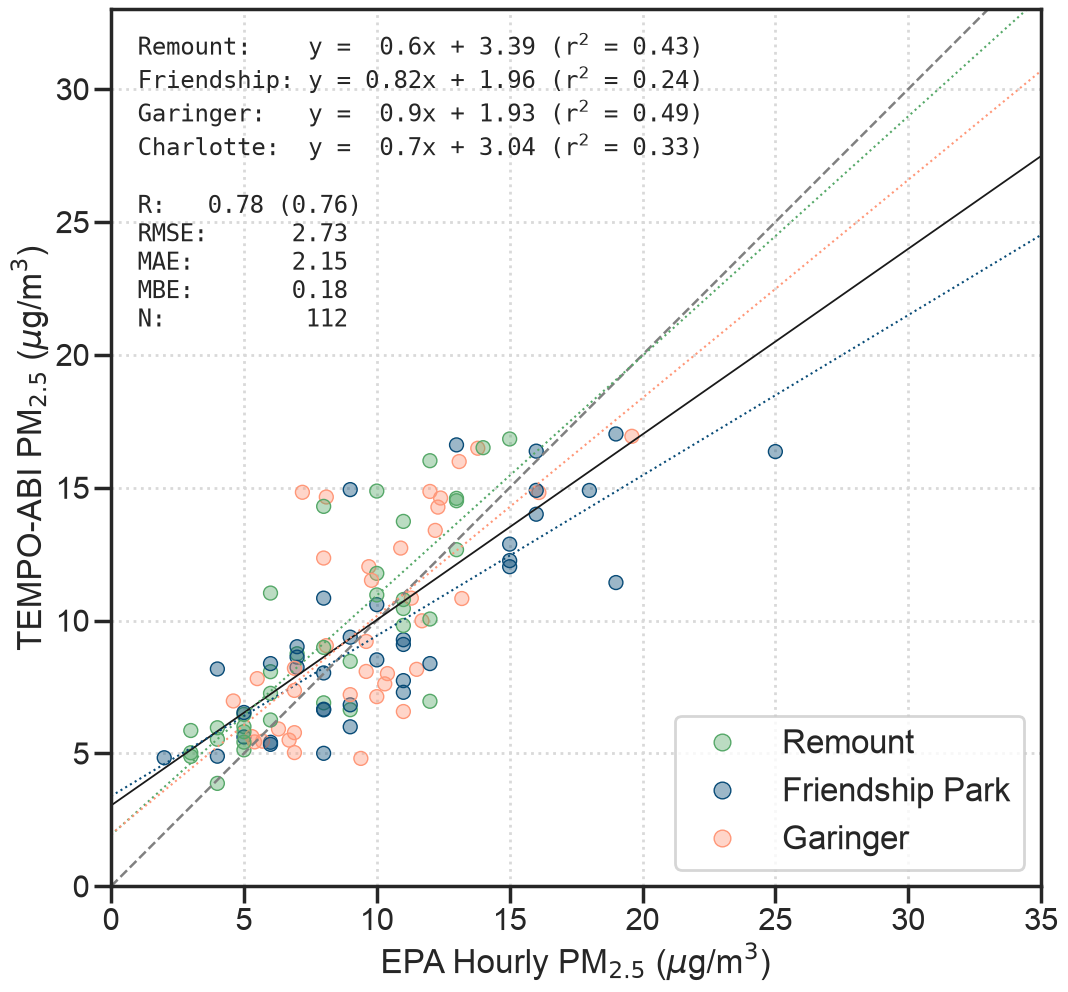

In [15]:
# CLT scatter

rc = {'axes.grid':True, 'grid.color':'.85', 'grid.linestyle':':'}
sns.set_theme(context='poster', style='ticks',rc=rc)

fig,ax = plt.subplots(figsize=(12,12))

pal = {'A':'g','B':'#084B77','C':'#FF9778'}

face_alpha = 0.4  # opacity for fill
edge_alpha = 1.0  # fully opaque outline

# map each row's category to its RGBA face/edge color, preserving df order
face_colors = pm_clt['site_label'].map(lambda k: mcolors.to_rgba(pal[k], alpha=face_alpha))
edge_colors = pm_clt['site_label'].map(lambda k: mcolors.to_rgba(pal[k], alpha=edge_alpha))

sc = sns.scatterplot(data=pm_clt, x = 'epa_pm', 
                     y = 'tempo_pm',s=10**2,
                     facecolor=list(face_colors),
                     edgecolor=list(edge_colors),
                     linewidth=1,alpha=None)

ax.set( xlabel = r'EPA Hourly PM$_{2.5}$ ($\mu$g/m$^3$)',
        ylabel = r'TEMPO-ABI PM$_{2.5}$ ($\mu$g/m$^3$)',  
        xlim=(0,35), xticks=np.arange(0,36,5),
        ylim=(0,33), yticks=np.arange(0,33,5),
        aspect='equal')

pearson_r_clt, spearman_rho_clt, rmse_clt, mae_clt, mbe_clt, slope_clt, int_clt,r2_clt= stats(pm_clt)
pearson_r_41, spearman_rho_41, rmse_41, mae_41, mbe_41, slope_41, int_41,r2_41 =stats(pm_41)
pearson_r_45, spearman_rho_45, rmse_45, mae_45, mbe_45, slope_45, int_45,r2_45 =stats(pm_45)
pearson_r_48, spearman_rho_48, rmse_48, mae_48, mbe_48, slope_48, int_48,r2_48 =stats(pm_48)
ax.text( 1, 20, (

        f"{'Remount:':11} y = {np.round(slope_45,2):4}x + {np.round(int_45,2):4} "
        r"(r$^2$ = "f"{np.round(r2_45**2,2)})\n"
        f"{'Friendship:':11} y = {np.round(slope_48,2):4}x + {np.round(int_48,2):4} "
        r"(r$^2$ = "f"{np.round(r2_48**2,2)})\n"
        f"{'Garinger:':11} y = {np.round(slope_41,2):4}x + {np.round(int_41,2):4} "
        r"(r$^2$ = "f"{np.round(r2_41**2,2)})\n"
        f"{'Charlotte:':11} y = {np.round(slope_clt,2):4}x + {np.round(int_clt,2):4} "
        r"(r$^2$ = "f"{np.round(r2_clt**2,2)})\n\n"

        f"{'R:':5}{spearman_rho_clt} ({pearson_r_clt})\n"
        f"{'RMSE:':10}{rmse_clt:5}\n"
        f"{'MAE:':10}{mae_clt:5}\n"
        f"{'MBE:':10}{mbe_clt:5}\n"
        f"{'N:':10}{len(pm_clt):5}\n"
        ), size = 17,font='monospace')

# build legend handles manually since there's only one scatter collection now
labels_map = {'A':f'Remount',
              'B':f'Friendship Park',
              'C':f'Garinger'}
legend_handles = [plt.Line2D([0], [0], marker='o', linestyle='none',
        markerfacecolor=mcolors.to_rgba(color, alpha=face_alpha),
        markeredgecolor=mcolors.to_rgba(color, alpha=edge_alpha),
        markersize=12, label=labels_map[k])
for k, color in pal.items()]

leg = ax.legend(handles=legend_handles,
                loc="lower right", markerscale=1,
                fontsize='medium')

ax.axline((0, 0), slope=1, c='grey', ls='--', lw=1.8)
ax.axline((0,int_clt),slope=slope_clt,c='k',ls='-',lw=1.3)
ax.axline((0,int_41),slope=slope_41,c='g',ls=':',lw=1.5)
ax.axline((0,int_45),slope=slope_45,c='#084B77',ls=':',lw=1.5)
ax.axline((0,int_48),slope=slope_48,c='#FF9778',ls=':',lw=1.5)

fig.savefig(Path.cwd()/'figs/clt_scatter.svg',bbox_inches = 'tight')

Plot urban/rural scatter plot

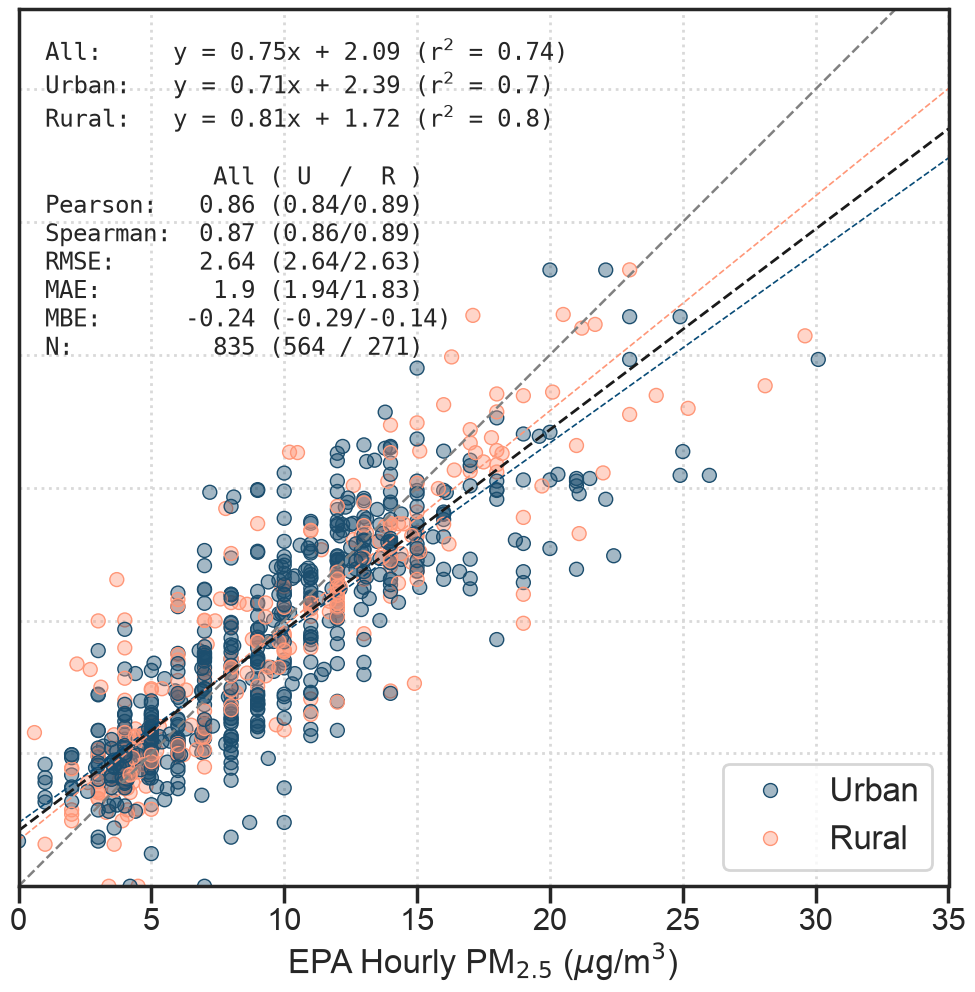

In [14]:
# Urban/rural scatter plot
def sct_URA(df,countylist: list[int] = nc_countylist):
        df = df[df['countyFIPS'].isin(countylist)]
        pm_u = df[df['URA']=='U']
        pm_r = df[df['URA']=='R']

        pearson_r, spearman_rho, rmse, mae, mbe, slope, intercept, r2 = stats(df)
        pearson_r_u, spearman_rho_u, rmse_u, mae_u, mbe_u, slope_u, intercept_u,r2_u = stats(pm_u)
        pearson_r_r, spearman_rho_r, rmse_r, mae_r, mbe_r, slope_r, intercept_r,r2_r  = stats(pm_r)

        rc = {#'axes.labelsize':16,'xtick.labelsize':12,'ytick.labelsize':12,
                'axes.grid':True, 'grid.color':'.85', 'grid.linestyle':':','ytick.left':False}
        sns.set_theme(context='poster', style='ticks',rc=rc)
        fig,ax = plt.subplots(figsize=(12,12))

        # add to axis: diagonal line, labels/limits/ticks, title
        ax.axline((0,intercept_u),slope=slope_u,c='#084B77',ls='--',lw=1.2)
        ax.axline((0,intercept_r),slope=slope_r,c='#FF9778',ls='--',lw=1.2)
        ax.axline((0, 0), slope=1, c='grey', ls='--', lw=1.8)
        ax.axline((0,intercept),slope=slope,c='k',ls='--',lw=2)
        ax.text( 1, 20, (
                f"{'All:':8} y = {np.round(slope,2):4}x + {np.round(intercept,2):4} "
                r"(r$^2$ = "f"{np.round(r2,2)})\n"
                f"{'Urban:':8} y = {np.round(slope_u,2):4}x + {np.round(intercept_u,2):4} "
                r"(r$^2$ = "f"{np.round(r2_u,2)})\n"
                f"{'Rural:':8} y = {np.round(slope_r,2):4}x + {np.round(intercept_r,2):4} "
                r"(r$^2$ = "f"{np.round(r2_r,2)})\n\n"

                f"{'':12}{'All'} ( U  /  R )\n"
                f"{'Pearson:':10}{pearson_r:5} ({pearson_r_u}/{pearson_r_r})\n"
                f"{'Spearman:':10}{spearman_rho:5} ({spearman_rho_u}/{spearman_rho_r})\n"
                f"{'RMSE:':10}{rmse:5} ({rmse_u:}/{rmse_r})\n"
                f"{'MAE:':10}{mae:5} ({mae_u}/{mae_r})\n"
                f"{'MBE:':10}{mbe:5} ({mbe_u}/{mbe_r})\n"
                f"{'N:':10}{len(df):5} ({len(pm_u)} / {len(pm_r)})"
                ), size = 17,font='monospace')

        ax.set(xlabel = r'EPA Hourly PM$_{2.5}$ ($\mu$g/m$^3$)',
                xlim=(0,35), xticks=np.arange(0,36,5),
                ylim=(0,33), yticklabels=([]),
                aspect='equal')

        palette = {'U': "#1c4e6e", 'R':"#FF9778"}#"#ff5035"}
        face_alpha = 0.4
        edge_alpha = 1.0  # fully opaque outline

        # map each row's category to its RGBA face/edge color, preserving df order
        face_colors = df['URA'].map(lambda k: mcolors.to_rgba(palette[k], alpha=face_alpha))
        edge_colors = df['URA'].map(lambda k: mcolors.to_rgba(palette[k], alpha=edge_alpha))

        sc = ax.scatter( df['epa_pm'], df['tempo_pm'], s=10**2,
                        facecolor=list(face_colors),
                        edgecolor=list(edge_colors),
                        linewidth=1,alpha=None)

        # build legend handles manually since there's only one scatter collection now
        labels_map = {'U': f'Urban', 'R': f'Rural'}
        legend_handles = [plt.Line2D([0], [0], marker='o', linestyle='none',
                markerfacecolor=mcolors.to_rgba(color, alpha=face_alpha),
                markeredgecolor=mcolors.to_rgba(color, alpha=edge_alpha),
                markersize=10, label=labels_map[k])
        for k, color in palette.items()]

        leg = ax.legend(handles=legend_handles,
                        loc="lower right", markerscale=1,
                        fontsize='medium')
        fig.savefig(Path.cwd()/'figs/URA_scatter_NC.svg',bbox_inches = 'tight')
sct_URA(pm_df)